In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [58]:
# Load the cleaned dataset
import pandas as pd
df = pd.read_csv(r"C:\Users\chyj2\OneDrive\Desktop\baltimore-crime-analytics\data\cleaned\cleaned_crime_data.csv")

In [59]:
print(df.columns)

Index(['rowid', 'ccnumber', 'crimedatetime', 'crimecode', 'description',
       'inside_outside', 'weapon', 'post', 'gender', 'age', 'race',
       'ethnicity', 'location', 'old_district', 'new_district', 'neighborhood',
       'latitude', 'longitude', 'geolocation', 'premisetype',
       'total_incidents', 'x', 'y', 'year', 'month', 'month_name',
       'day_of_week'],
      dtype='object')


In [60]:
# 1. Group the main dataframe 'df' by year and month to get the monthly total
monthly_crime = df.groupby(["year", "month"]).size().reset_index(name="total_crimes")

In [61]:
# 2. Create a  datetime column for plotting the rolling average 
monthly_crime["date"] = pd.to_datetime(
    monthly_crime["year"].astype(int).astype(str) + "-" + 
    monthly_crime["month"].astype(int).astype(str) + "-01"
)

In [62]:
# Filter out the placeholder/junk historical dates
# Let's keep only the data from 2012 onwards, where the reliable reporting begins
monthly_crime = monthly_crime[monthly_crime['date'].dt.year >= 2012]

In [63]:
#calculate the 12-month rolling average on the clean data
monthly_crime['rolling_mean'] = monthly_crime['total_crimes'].rolling(window=12).mean()

In [64]:
# Ensure seaborn style for a clean look
sns.set_theme(style="whitegrid")

In [65]:
# Set up the plot
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='date', ylabel='total_crimes'>

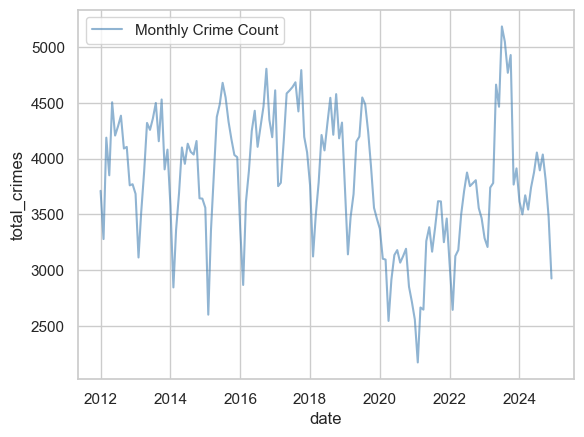

In [66]:
# Plot the raw monthly crime counts
sns.lineplot(
    data=monthly_crime, 
    x='date', 
    y='total_crimes', 
    color='steelblue', 
    alpha=0.6, 
    linewidth=1.5, 
    label='Monthly Crime Count'
)

<Axes: xlabel='date', ylabel='rolling_mean'>

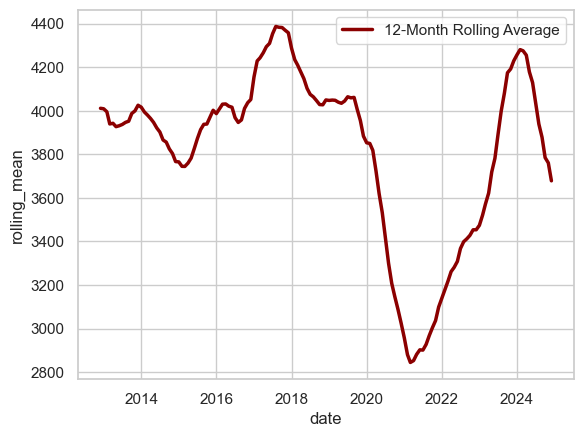

In [67]:
# Plot the 12-month rolling average
sns.lineplot(
    data=monthly_crime, 
    x='date', 
    y='rolling_mean', 
    color='darkred', 
    linewidth=2.5, 
    label='12-Month Rolling Average'
)

2013 to 2018 (Initial Peak): The rolling average hovered around 4,000 incidents per month before experiencing a notable surge, peaking at roughly 4,400 crimes per month around 2017/2018.

2018 to 2021 (Steep Decline): Following the 2018 peak, crime rates began to fall. This decline accelerated dramatically around 2020, bottoming out at a decade-low of approximately 2,800 crimes per month in early 2021.

2021 to 2024 (Rapid Rebound): Immediately after the 2021 trough, the rolling mean shows a sharp, V-shaped recovery. Crime climbed rapidly over the next three years, reaching a secondary peak of about 4,300 crimes per month in 2024.

2024 to 2025 (Recent Downtrend): After hitting the 2024 peak, the trend reverses sharply again, dropping steeply to roughly 3,700 crimes per month by the end of the graphed period.

In [68]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [69]:
# 1. Build and fit the model on the clean historical data
model = ExponentialSmoothing(
    monthly_crime["total_crimes"], 
    trend="add", 
    seasonal="add", 
    seasonal_periods=12
)
fit = model.fit()

In [70]:
# 2. Forecast the next 12 periods
forecast = fit.forecast(12)

# 3. Create the forecast DataFrame (using the .values fix so the index aligns)
forecast_df = pd.DataFrame({
    "date": pd.date_range(monthly_crime["date"].max() + pd.DateOffset(months=1), periods=12, freq="MS"),
    "forecasted_crimes": forecast.values 
})

<Axes: xlabel='date', ylabel='total_crimes'>

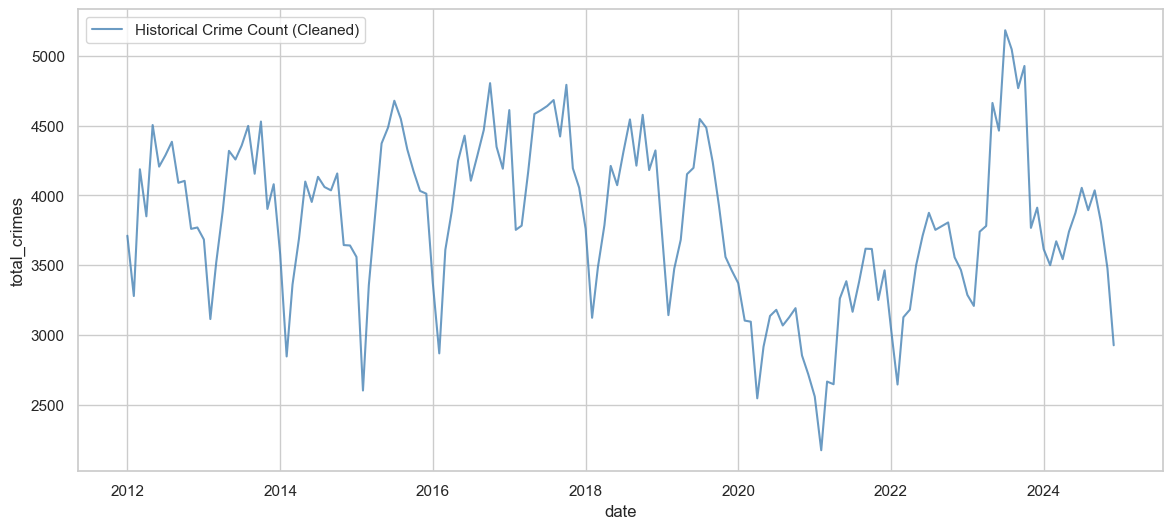

In [71]:
# 4. Visualize the Historical Data + The New Forecast
plt.figure(figsize=(14, 6))

# Plot historical crime data
sns.lineplot(
    data=monthly_crime, 
    x='date', 
    y='total_crimes', 
    color='steelblue', 
    alpha=0.8,
    label='Historical Crime Count (Cleaned)'
)

<Axes: xlabel='date', ylabel='forecasted_crimes'>

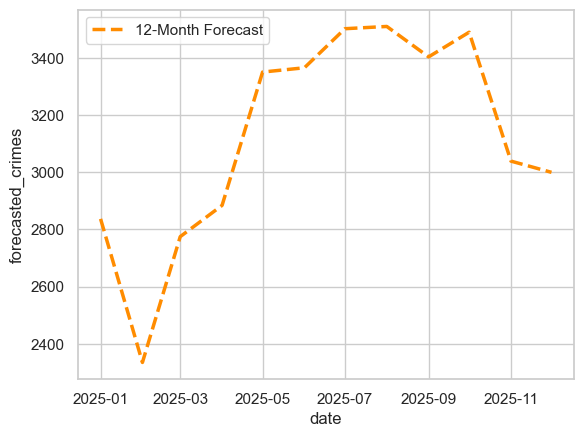

In [72]:
# Plot the 12-month forecast
sns.lineplot(
    data=forecast_df, 
    x='date', 
    y='forecasted_crimes', 
    color='darkorange', 
    linewidth=2.5, 
    linestyle='--',
    label='12-Month Forecast'
)

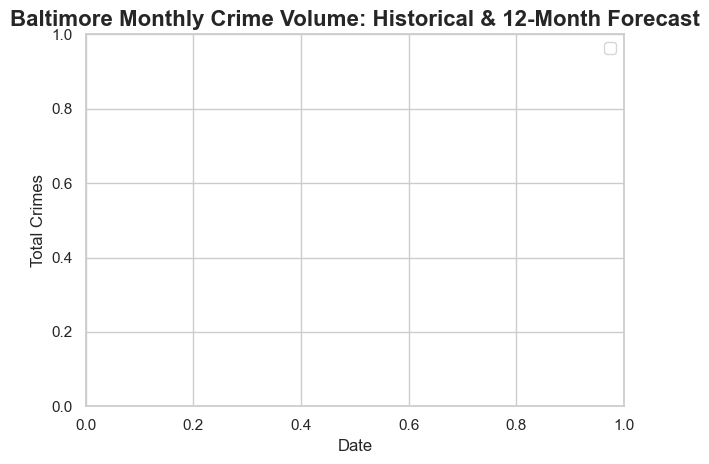

In [73]:
# Formatting the chart
plt.title('Baltimore Monthly Crime Volume: Historical & 12-Month Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Crimes', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()

In [56]:
# Export the 12-month forecast to the outputs folder
#forecast_df.to_csv(r"C:\Users\chyj2\OneDrive\Desktop\baltimore-crime-analytics\outputs\tables\crime_forcast.csv", index=False)

#print("Forecast successfully exported to CSV!")


Forecast successfully exported to CSV!
